In [54]:
# Imports
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams['figure.figsize'] = (15.0, 8.0) # set default size of plots
plt.rcParams['figure.facecolor'] = 'white'

pd.set_option('display.max_rows', None)

matplotlib.rcParams.update({'font.size': 15})

In [55]:
TIME_RETRIEVAL_REE = 0
TIME_RETRIEVAL_TEE = 5
TIME_RETRIEVAL_REE_WASM = 0
TIME_RETRIEVAL_TEE_WASM = 6

In [56]:
def compute_mean_std(name, time):
    df = pd.DataFrame(columns = ["Name","Time"])
    df["Name"] = name
    df["Time"] = time
    
    result = pd.DataFrame(columns = ["Mean","Std"])
    result["Mean"] = df.groupby("Name")["Time"].median() #df.groupby("Size")["Time"].apply(stats.gmean)
    result["Std"] = df.groupby("Name")["Time"].std() #df.groupby("Size")["Time"].apply(stats.gstd)
    
    return result

def formatForLatex(n, digits_round = 3):
    roundedAsString = str(round(n, digits_round))
    if "." in roundedAsString:
        roundedAsString = roundedAsString.rstrip("0")
        roundedAsString = roundedAsString.rstrip(".")
    return f"{roundedAsString}"

In [57]:
#
## REE (Native) dataset
#

In [58]:
# Import the dataset
ree_native_raw = pd.read_csv("../logs/polybench/ree-native.csv", names = ["Name","Time"])
ree_native_raw["Name"] = ree_native_raw["Name"].str.replace("_native", "")

ree_native_raw

,Name,Time
0,2mm,0.023411
1,2mm,0.023464
2,2mm,0.023632
3,2mm,0.023510
4,2mm,0.024489
5,2mm,0.024944
6,2mm,0.023314
7,2mm,0.024215
8,2mm,0.023460
9,2mm,0.023676


In [59]:
# Adapt the time according the retrieval of the time
ree_native = ree_native_raw

ree_native["Time"] = ree_native["Time"] # - 2*TIME_RETRIEVAL_REE/2

ree_native

,Name,Time
0,2mm,0.023411
1,2mm,0.023464
2,2mm,0.023632
3,2mm,0.023510
4,2mm,0.024489
5,2mm,0.024944
6,2mm,0.023314
7,2mm,0.024215
8,2mm,0.023460
9,2mm,0.023676


In [60]:
#
## REE (Wasm) dataset
#

In [61]:
# Import the dataset
ree_wasm_raw = pd.read_csv("../logs/polybench/ree-wasm.csv", names = ["Name","Time"])
ree_wasm_raw["Name"] = ree_wasm_raw["Name"].str.replace(".aot", "")

ree_wasm_raw

,Name,Time
0,2mm,0.027478
1,2mm,0.027500
2,2mm,0.027614
3,2mm,0.027509
4,2mm,0.027408
5,2mm,0.027784
6,2mm,0.027688
7,2mm,0.027502
8,2mm,0.027775
9,2mm,0.027372


In [62]:
# Adapt the time according the retrieval of the time
ree_wasm = ree_wasm_raw

ree_wasm["Time"] = ree_wasm["Time"] # - 2*TIME_RETRIEVAL_REE_WASM/2

ree_wasm

,Name,Time
0,2mm,0.027478
1,2mm,0.027500
2,2mm,0.027614
3,2mm,0.027509
4,2mm,0.027408
5,2mm,0.027784
6,2mm,0.027688
7,2mm,0.027502
8,2mm,0.027775
9,2mm,0.027372


In [63]:
#
## TEE dataset
#

In [64]:
# Import the dataset
tee_raw = pd.read_csv("../logs/polybench/tee.csv", names = ["Name","Time"])
tee_raw["Name"] = tee_raw["Name"].str.replace(".aot", "")

tee_raw

,Name,Time
0,2mm,0.028903
1,2mm,0.028835
2,2mm,0.028492
3,2mm,0.027494
4,2mm,0.027684
5,2mm,0.028812
6,2mm,0.028832
7,2mm,0.028763
8,2mm,0.027608
9,2mm,0.060795


In [65]:
# Adapt the time according the retrieval of the time
tee = tee_raw

tee["Time"] = tee["Time"] # - 2*TIME_RETRIEVAL_TEE_WASM/2

tee

,Name,Time
0,2mm,0.028903
1,2mm,0.028835
2,2mm,0.028492
3,2mm,0.027494
4,2mm,0.027684
5,2mm,0.028812
6,2mm,0.028832
7,2mm,0.028763
8,2mm,0.027608
9,2mm,0.060795


In [66]:
#
## Export
#

In [67]:
# Shorten the names of the experiments
short_names = {
    "adi": "adi",
    "gramschmidt": "gra",
    "covariance": "cov",
    "correlation": "cor",
    "trmm": "trm",
    "lu": "lu",
    "symm": "sym",
    "seidel-2d": "s2d",
    "floyd-warshall": "flo",
    "2mm": "2mm",
    "mvt": "mvt",
    "deriche": "der",
    "3mm": "3mm",
    "trisolv": "tri",
    "gesummv": "ges",
    "doitgen": "doi",
    "bicg": "bic",
    "ludcmp": "lud",
    "gemver": "gev",
    "cholesky": "cho",
    "nussinov": "nus",
    "heat-3d": "h3d",
    "atax": "ata",
    "durbin": "dur",
    "syr2k": "s2k",
    "jacobi-2d": "j2d",
    "fdtd-2d": "f2d",
    "syrk": "syr",
    "jacobi-1d": "j1d",
    "gemm": "gem",
}

for k, v in short_names.items():
    ree_native["Name"] = ree_native["Name"].replace(k, v)
    ree_wasm["Name"] = ree_wasm["Name"].replace(k, v)
    tee["Name"] = tee["Name"].replace(k, v)

In [68]:
# Normalize the results based on REE (Native) time
ree_native_normalized = pd.DataFrame()
ree_wasm_normalized = pd.DataFrame()
tee_normalized = pd.DataFrame()

for col in ree_native:
    if col == "Name":
        tee_normalized[col] = tee[col]
        ree_wasm_normalized[col] = ree_wasm[col]
        ree_native_normalized[col] = ree_native[col]
    else:
        tee_normalized[col] = tee[col] / ree_native[col]
        ree_wasm_normalized[col] = ree_wasm[col] / ree_native[col]
        ree_native_normalized[col] = 1
    
tee_normalized

,Name,Time
0,2mm,1.234591
1,2mm,1.228904
2,2mm,1.205653
3,2mm,1.169460
4,2mm,1.130467
5,2mm,1.155067
6,2mm,1.236682
7,2mm,1.187817
8,2mm,1.176812
9,2mm,2.567790


In [69]:
# Compute the mean and std
ree_native_export = pd.DataFrame()

# ree_native_export = ree_native_export.append(compute_mean_std(ree_native_normalized["Name"], ree_native_normalized["Time"]))
# ree_native_exprot = pd.concat([ree_native_export, compute_mean_std(ree_native_normalized["Name"], ree_native_normalized["Time"])])
ree_native_export = compute_mean_std(ree_native_normalized["Name"], ree_native_normalized["Time"]).copy()
ree_native_export


,Mean,Std
Name,,
2mm,1.0,0.0
3mm,1.0,0.0
adi,1.0,0.0
ata,1.0,0.0
bic,1.0,0.0
cho,1.0,0.0
cor,1.0,0.0
cov,1.0,0.0
der,1.0,0.0


In [70]:
# Compute the mean and std
ree_wasm_export = pd.DataFrame()

ree_wasm_export = compute_mean_std(ree_wasm_normalized["Name"], ree_wasm_normalized["Time"]).copy()
ree_wasm_export

,Mean,Std
Name,,
2mm,1.166794,0.028915
3mm,1.101066,0.017054
adi,0.871454,0.006432
ata,1.550199,0.175478
bic,0.812027,0.085640
cho,1.161408,0.007022
cor,1.424329,0.065543
cov,1.396189,0.063816
der,0.901445,0.073511


In [71]:
# Compute the mean and std
tee_export = pd.DataFrame()

tee_export = compute_mean_std(tee_normalized["Name"], tee_normalized["Time"]).copy()
tee_export

,Mean,Std
Name,,
2mm,1.203509,0.276801
3mm,1.164558,0.176864
adi,0.867515,0.218107
ata,1.589103,0.576824
bic,0.826691,0.436255
cho,1.167316,0.272217
cor,1.411969,0.225939
cov,1.395591,0.448222
der,0.928816,0.236352


In [72]:
#
## Temp visualisation
#

Text(0.5, 0, 'Times slower than REE native')

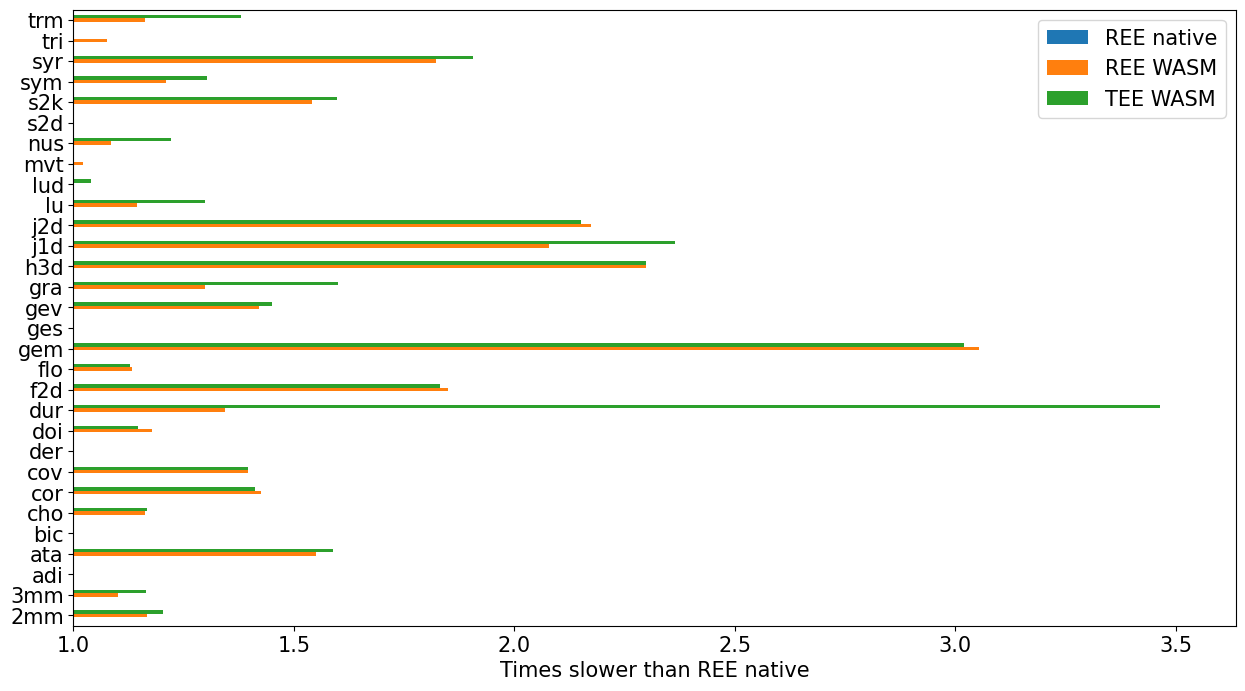

In [89]:
df = pd.DataFrame({'REE native': ree_native_export["Mean"],
                   'REE WASM': ree_wasm_export["Mean"],
                   'TEE WASM': tee_export["Mean"]}, index=ree_native_export.index.values)
ax = df.plot.barh()
ax.set_xlim(1,)
ax.set_xlabel("Times slower than REE native")

Text(0.5, 0, 'Time (μs)')

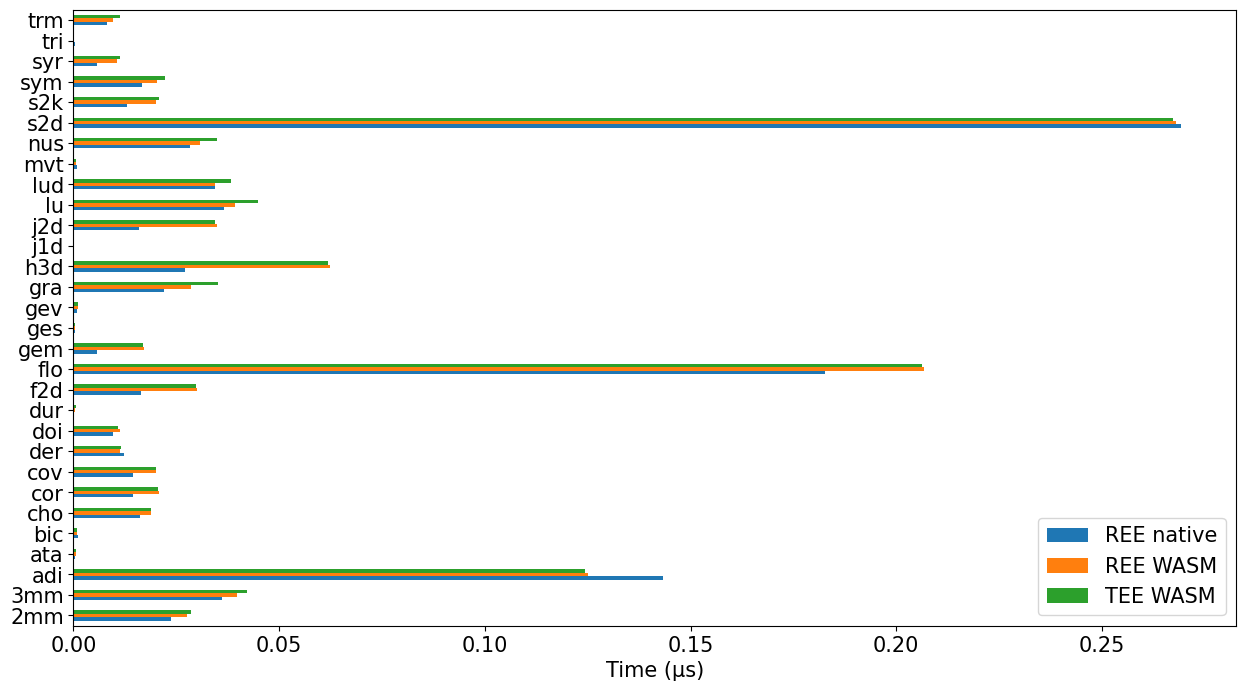

In [87]:
tee_time = compute_mean_std(tee["Name"], tee["Time"]).copy()
ree_time = compute_mean_std(ree_native["Name"], ree_native["Time"]).copy()
ree_wasm_time = compute_mean_std(ree_wasm["Name"], ree_wasm["Time"]).copy()


df = pd.DataFrame({'REE native': ree_time["Mean"],
                   'REE WASM': ree_wasm_time["Mean"],
                   'TEE WASM': tee_time["Mean"]}, index=ree_time.index.values)
ax = df.plot.barh()
ax.set_xlabel("Time (μs)")

In [74]:
tee_mean_of_mean = tee_export["Mean"].mean()
tee_mean_of_mean

np.float64(1.4845313159782172)

In [75]:
ree_wasm_mean_of_mean = ree_wasm_export["Mean"].mean()
ree_wasm_mean_of_mean

np.float64(1.367264750350439)

In [76]:
# Retrieve the name of the experiment, order by TEE normalized run time
for name in tee_export.sort_values(by=["Mean"]).index:
    print(f"{name},", end = '')

bic,ges,adi,der,mvt,tri,s2d,lud,flo,doi,3mm,cho,2mm,nus,lu,sym,trm,cov,cor,gev,ata,s2k,gra,f2d,syr,j2d,h3d,j1d,gem,dur,

In [77]:
# Export CSV
#
# File format: experiment_name, mean, stddev

ree_wasm_export.to_csv('../logs/polybench/ree_wasm_formatted.csv')
tee_export.to_csv('../logs/polybench/tee_formatted.csv')

In [78]:
# Export LaTeX

prefix = "Polybench"

floyd_warshall = tee_export.loc[tee_export.index == "flo"]["Mean"].values[0]
nussinov = tee_export.loc[tee_export.index == "nus"]["Mean"].values[0]

def write(file, column_name, number, digits_round = 3):
    f.write(f"\\def\\bm{prefix}{column_name}{{{formatForLatex(number, digits_round)}}}\n")

f = open('../logs/polybench/export.tex', "w")
write(f, "TeeGlobalSlowdown", tee_mean_of_mean, 2)
write(f, "ReeWasmGlobalSlowdown", ree_wasm_mean_of_mean, 2)
write(f, "FloydWarshallSlowdown", tee_export.loc[tee_export.index == "flo"]["Mean"].values[0])
write(f, "NussinovSlowdown", tee_export.loc[tee_export.index == "nus"]["Mean"].values[0])
write(f, "GlobalSlowdownPercent", (tee_mean_of_mean - 1) * 100, 1)
write(f, "FloydWarshallSlowdownPercent", (floyd_warshall - 1) * 100, 1)
write(f, "NussinovSlowdownPercent", (nussinov - 1) * 100, 1)
write(f, "FloydWarshallNussinovSlowdownPercent", (floyd_warshall - 1) * 100, 0)
f.close()